### import utils

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from a_utils import (
    keep_rows_with_any_filled,
    keep_positives,
    get_sym_severity,
    get_symptom_severity_score,
    is_abnormal_cxr,
    open_data,
    plot_fill_rates,
    build_model,
    compute_feature_importance,
    plot_feature_importance,
    plot_importance_vs_fill_rate,
    compute_shap_importance,
    plot_shap_importance,
    plot_shap_summary,
    compute_column_outcome_correlation,
    plot_outcome_correlation,
    log_column_names_with_single_unique_value,
    SYMPTOMS,
    VITALS,
    CXR_FIELDS,
    LABEL,
    LABEL_VALUES,
    logging
)

### load data

In [2]:
data = open_data()
log_column_names_with_single_unique_value(data)


### plot fill rates

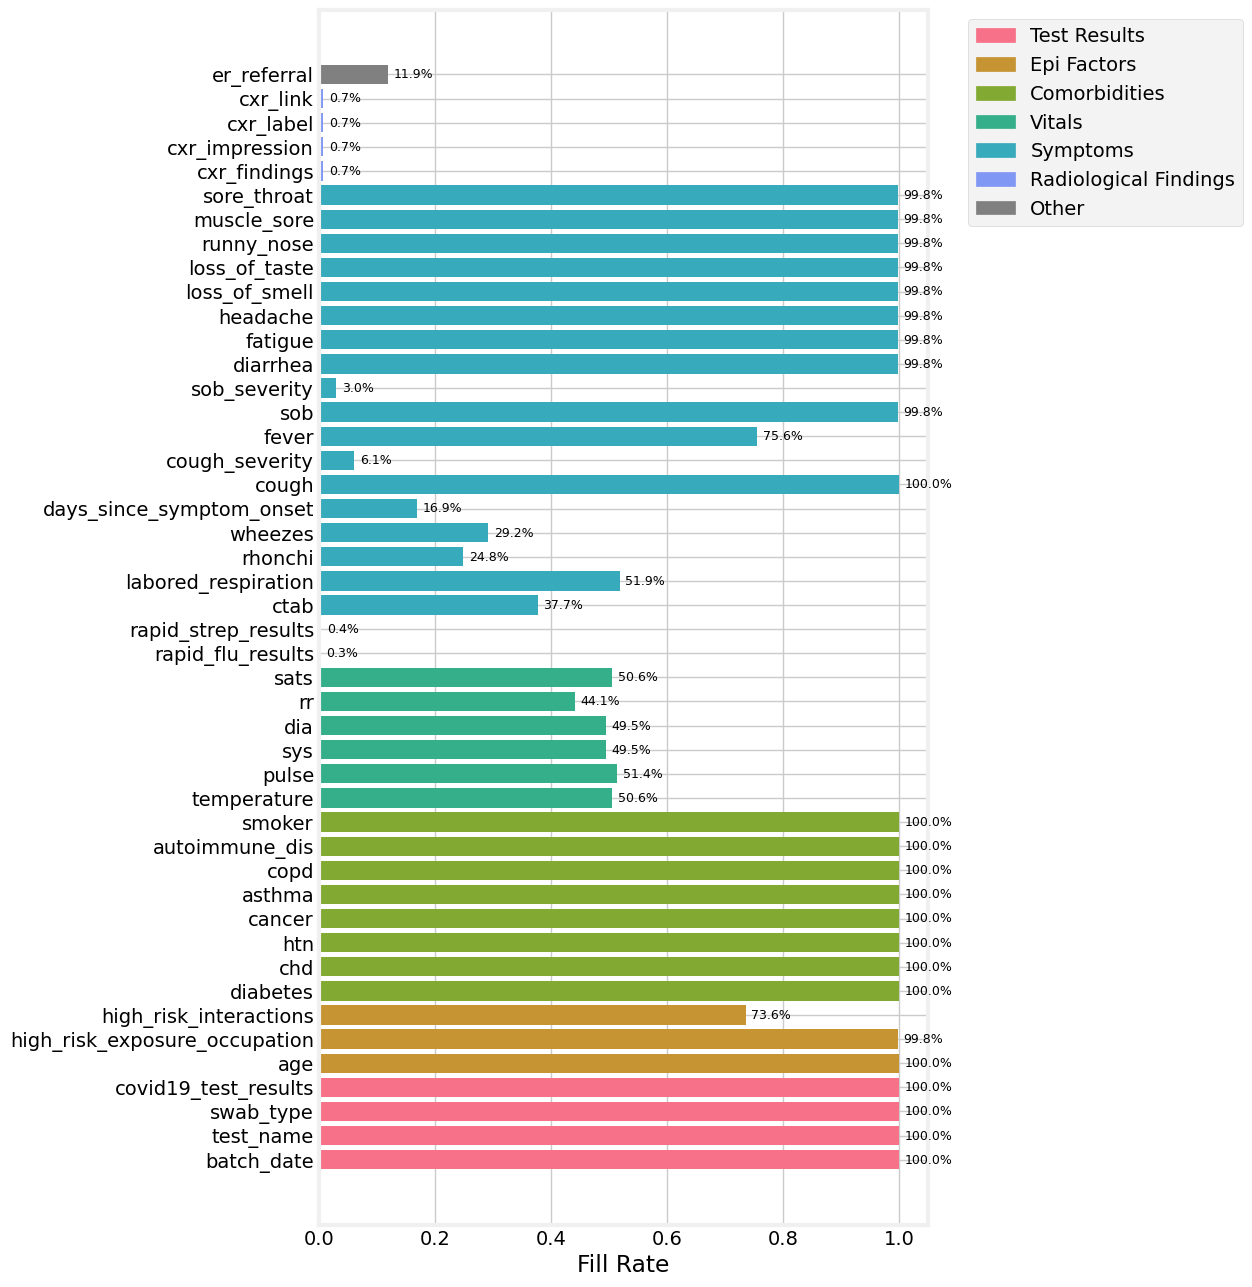

In [3]:
plot_fill_rates(data)


### process and filter data

In [4]:
positive_patients = keep_positives(data)
symptomatic_patients = keep_rows_with_any_filled(data, SYMPTOMS)
patients_with_vitals = keep_rows_with_any_filled(data, VITALS, col_type='numeric')

# see Appendix A for details on the CXR fields and the reason we drop them.
data = data.drop(columns=CXR_FIELDS, errors='ignore')

# add a column for the number of symptoms, only for rows that have at least one symptom filled in
data.loc[:, 'num_symptoms'] = data.loc[:, :].apply(
    lambda x: sum(1 for sym in SYMPTOMS if x[sym] == True), axis=1
)

# add a column for the symptom severity score, only for rows that have at least one symptom filled in
data['severity_score'] = data.apply(
    lambda x: get_symptom_severity_score(x), axis=1
)
data['sym_severity'] = data.severity_score.apply(
    lambda x: get_sym_severity(x)
)


INFO:root:Filtering out patients...


INFO:root:    ---- 93995 --> 26577 (28.27%)
INFO:root:Filtering out patients...
INFO:root:    ---- 93995 --> 49341 (52.49%)


### feature importance analysis

In [ ]:
classifier, X_train, y_train, X_test, y_test, fill_rates = build_model(data)
importance_df = compute_feature_importance(classifier, X_train, fill_rates)
importance_df.head(10)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

y_proba = classifier.predict_proba(X_test)[:, 1]

# Precision/recall tradeoff across thresholds
thresholds_to_check = [0.05, 0.10, 0.20, 0.30, 0.50]
logging.info(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'N_pred_pos':>12}")
for t in thresholds_to_check:
    y_pred_t = (y_proba >= t).astype(int)
    logging.info(
        f"{t:>10.2f} "
        f"{precision_score(y_test, y_pred_t):>10.4f} "
        f"{recall_score(y_test, y_pred_t):>10.4f} "
        f"{f1_score(y_test, y_pred_t):>8.4f} "
        f"{y_pred_t.sum():>12}"
    )

# Adjust THRESHOLD to trade precision vs. recall
THRESHOLD = 0.30
y_pred = (y_proba >= THRESHOLD).astype(int)

logging.info(f'\n--- Metrics at threshold={THRESHOLD} ---')
logging.info(f'Accuracy:              {accuracy_score(y_test, y_pred):.4f}')
logging.info(f'F1 score:              {f1_score(y_test, y_pred):.4f}')
logging.info(f'Precision (positives): {precision_score(y_test, y_pred):.4f}')
logging.info(f'Recall (positives):    {recall_score(y_test, y_pred, pos_label=1):.4f}')
logging.info(f'Recall (negatives):    {recall_score(y_test, y_pred, pos_label=0):.4f}')

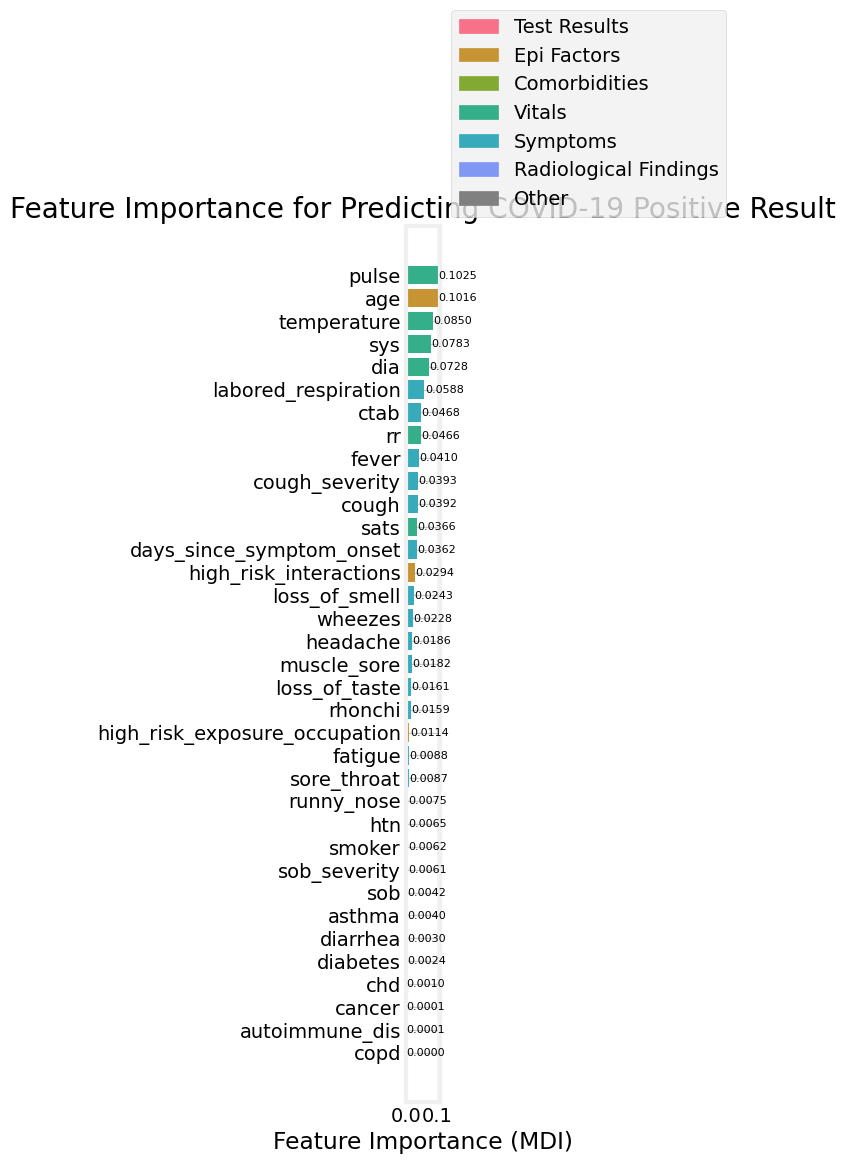

In [6]:
plot_feature_importance(importance_df)

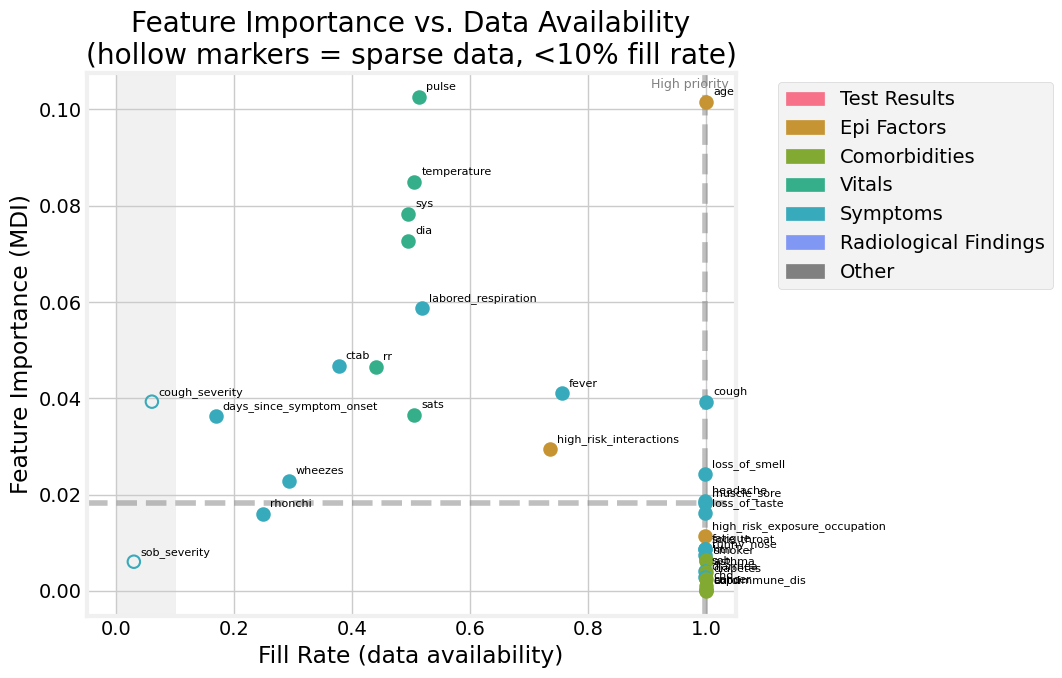

In [7]:
plot_importance_vs_fill_rate(importance_df)

### SHAP feature importance analysis

In [ ]:
shap_df, shap_values, X_shap = compute_shap_importance(classifier, X_train, y_train, fill_rates)
shap_df.head(10)

In [ ]:
plot_shap_importance(shap_df)

In [ ]:
plot_shap_summary(shap_values, X_shap)

### Appendix a: the reason to drop the CXR columns

The cxr columns have a very low fill rate (0.7%), and as you can see below, the correlation between positive and negative is pretty similar among them. Thus, I decided to drop them.

In [ ]:
has_cxr = ~data['cxr_impression'].isnull()

# add a column for whether the cxr impression is abnormal or not, only for rows that have a cxr impression
data.loc[has_cxr, 'is_abnormal_cxr'] = data.loc[
    has_cxr, 'cxr_impression'
].apply(is_abnormal_cxr)

In [ ]:
cxr_corr_df = compute_column_outcome_correlation(data, "is_abnormal_cxr")
cxr_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col=LABEL,
    rate_col='is_abnormal_cxr',
    group_values=LABEL_VALUES,
    rate_positive_value=True,
    ylabel='Patients with Abnormal CXR (%)',
    title='Abnormal CXR Rate by COVID-19 Outcome',
)

### Appendix B: Rapid Results Columns Outcome Correlation

For each rapid test column (`rapid_flu_results`, `rapid_strep_results`), we compute the COVID-19 positive rate among patients who tested positive vs. negative on the rapid test, along with the point-biserial correlation and p-value.

In [ ]:
data['rapid_flu_positive'] = data['rapid_flu_results'] == 'Positive'
flu_corr_df = compute_column_outcome_correlation(data, 'rapid_flu_positive')
flu_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col='rapid_flu_results',
    rate_col=LABEL,
    group_values=['Positive', 'Negative'],
    rate_positive_value='Positive',
    xlabel='rapid_flu_results Result',
    ylabel='COVID-19 Positive Rate (%)',
    title='rapid_flu_results: COVID-19 Positive Rate by Rapid Result',
)

In [ ]:
data['rapid_strep_positive'] = data['rapid_strep_results'] == 'Positive'
strep_corr_df = compute_column_outcome_correlation(data, 'rapid_strep_positive')
strep_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col='rapid_strep_results',
    rate_col=LABEL,
    group_values=['Positive', 'Negative'],
    rate_positive_value='Positive',
    xlabel='rapid_strep_results Result',
    ylabel='COVID-19 Positive Rate (%)',
    title='rapid_strep_results: COVID-19 Positive Rate by Rapid Result',
)